# S1 — LSTM MFCC Baseline
## AudioGuard FYP | SER Track
**Purpose**: Baseline SER model using a 2-layer stacked LSTM on 40-coefficient MFCCs extracted from TESS audio (7 emotions, 2800 files). Uses TensorFlow/Keras (NOT PyTorch). Provides a non-transformer baseline to compare against S2–S7.

**Expected runtime**: ~15–30 min on CPU (acceptable) / ~5–10 min on GPU

**Output**: `./outputs/S1_lstm_mfcc_baseline/`

In [1]:
%pip install tensorflow keras librosa scikit-learn pandas numpy tqdm \
             kaggle python-dotenv matplotlib seaborn soundfile --quiet
print('✓ Dependencies installed')

Note: you may need to restart the kernel to use updated packages.
✓ Dependencies installed


In [2]:
import os, sys, json, time, random
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from tqdm.notebook import tqdm
print('✓ All imports successful')

✓ All imports successful


In [3]:
# Cell 4 — Environment check (TensorFlow version, not PyTorch)
print(f'TensorFlow version: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU available: {len(gpus)} device(s)')
    for g in gpus:
        print(f'  {g.name}')
else:
    print('No GPU detected — training on CPU (~15-30 min, acceptable for LSTM)')
print(f'Python: {sys.version}')

TensorFlow version: 2.21.0
No GPU detected — training on CPU (~15-30 min, acceptable for LSTM)
Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [4]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f'Seeds set to {SEED}')

Seeds set to 42


In [5]:
CONFIG = {
    'model_id': 'S1',
    'model_name': 'LSTM-MFCC-Baseline (Keras)',
    'track': 'SER',
    'num_labels': 7,
    'epochs': 100,
    'batch_size': 32,
    'learning_rate': 0.001,
    'n_mfcc': 40,
    'sr': 16000,
    'max_frames': 216,
    'seed': 42,
    'output_dir': os.path.join('..', '..', 'outputs', 'S1_lstm_mfcc_baseline'),
    'dataset': 'TESS (2800 files, 7 emotions)',
}
os.makedirs(CONFIG['output_dir'], exist_ok=True)
LABEL_NAMES = ['neutral', 'happy', 'sad', 'angry', 'fear', 'disgust', 'surprise']
EMOTION_MAP = {'neutral': 0, 'happy': 1, 'sad': 2, 'angry': 3, 'fear': 4, 'disgust': 5, 'surprise': 6}
print('CONFIG loaded')

CONFIG loaded


In [6]:
# Cell 7 — Download TESS via Kaggle API if not already present
TESS_DIR = os.path.join('..', '..', 'datasets', 'tess')
os.makedirs(TESS_DIR, exist_ok=True)

tess_files = []
for root, dirs, files in os.walk(TESS_DIR):
    tess_files.extend([os.path.join(root, f) for f in files if f.endswith('.wav')])

if len(tess_files) > 100:
    print(f'✓ TESS already present: {len(tess_files)} .wav files — skipping download')
else:
    import os, subprocess
    kaggle_path = os.path.join(os.path.expanduser('~'), '.kaggle', 'kaggle.json')
    if not os.path.exists(kaggle_path):
        raise FileNotFoundError(
            f'kaggle.json not found at {kaggle_path}\n'
            'Download from: https://www.kaggle.com/settings → API → Create New Token'
        )
    print('Downloading TESS from Kaggle...')
    result = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', 'ejlok1/toronto-emotional-speech-set-tess',
         '-p', TESS_DIR, '--unzip', '--quiet'],
        capture_output=True, text=True)
    if result.returncode == 0:
        for root, dirs, files in os.walk(TESS_DIR):
            tess_files.extend([os.path.join(root, f) for f in files if f.endswith('.wav')])
        print(f'✓ TESS downloaded: {len(tess_files)} .wav files')
    else:
        print('✗ Download failed:', result.stderr)
        raise RuntimeError('TESS download failed. Check Kaggle credentials.')

✓ TESS already present: 5600 .wav files — skipping download


Sample file: ..\..\datasets\tess\TESS Toronto emotional speech set data\OAF_angry\OAF_back_angry.wav
MFCC shape: (216, 40) (frames x n_mfcc)


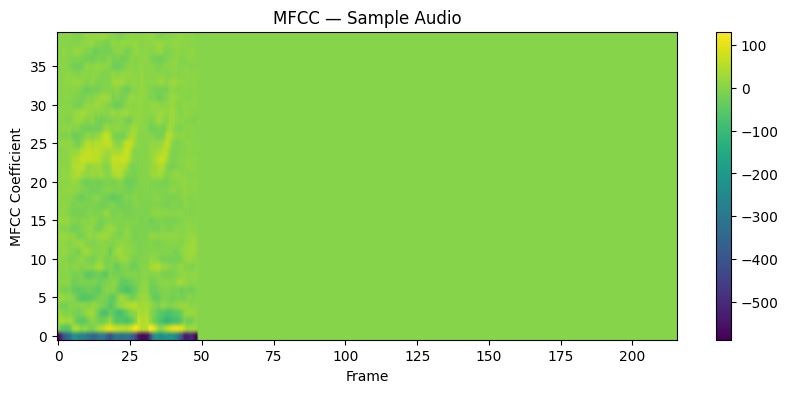

✓ MFCC extraction function ready


In [7]:
# Cell 8 — Feature extraction: librosa MFCCs
def extract_mfcc(filepath, n_mfcc=40, sr=16000, max_frames=216):
    """Load audio, resample to 16kHz, extract MFCC, pad/truncate to max_frames."""
    try:
        y, orig_sr = librosa.load(filepath, sr=sr, mono=True)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)  # shape: (n_mfcc, frames)
        mfcc = mfcc.T  # shape: (frames, n_mfcc)
        # Pad or truncate to max_frames
        if mfcc.shape[0] < max_frames:
            mfcc = np.pad(mfcc, ((0, max_frames - mfcc.shape[0]), (0, 0)), mode='constant')
        else:
            mfcc = mfcc[:max_frames]
        return mfcc.astype(np.float32)
    except Exception as e:
        return None

def get_tess_label(filepath):
    folder = os.path.basename(os.path.dirname(filepath)).lower()
    for key, val in EMOTION_MAP.items():
        if key in folder:
            return val
    return None

# Visualise MFCC for one sample file
sample_file = tess_files[0]
sample_mfcc = extract_mfcc(sample_file)
print(f'Sample file: {sample_file}')
print(f'MFCC shape: {sample_mfcc.shape} (frames x n_mfcc)')
plt.figure(figsize=(10, 4))
plt.imshow(sample_mfcc.T, aspect='auto', origin='lower', cmap='viridis')
plt.title('MFCC — Sample Audio'); plt.ylabel('MFCC Coefficient'); plt.xlabel('Frame')
plt.colorbar()
plt.savefig(os.path.join(CONFIG['output_dir'], 'sample_mfcc.png'), dpi=150)
plt.show()
print('✓ MFCC extraction function ready')

In [8]:
# Extract features for all TESS files
print(f'Extracting MFCCs from {len(tess_files)} TESS files...')
X, y = [], []
skipped = 0
for fp in tqdm(tess_files, desc='MFCC extraction'):
    label = get_tess_label(fp)
    if label is None:
        skipped += 1; continue
    mfcc = extract_mfcc(fp, CONFIG['n_mfcc'], CONFIG['sr'], CONFIG['max_frames'])
    if mfcc is None:
        skipped += 1; continue
    X.append(mfcc); y.append(label)

X = np.array(X, dtype=np.float32)  # (N, 216, 40)
y = np.array(y, dtype=np.int32)
print(f'✓ Features extracted: X={X.shape}, y={y.shape}, skipped={skipped}')
print(f'Class distribution:')
from collections import Counter
for k, v in sorted(Counter(y).items()):
    print(f'  {LABEL_NAMES[k]:10s} ({k}): {v}')

# Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)
print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Extracting MFCCs from 5600 TESS files...


MFCC extraction:   0%|          | 0/5600 [00:00<?, ?it/s]

✓ Features extracted: X=(5600, 216, 40), y=(5600,), skipped=0
Class distribution:
  neutral    (0): 800
  happy      (1): 800
  sad        (2): 800
  angry      (3): 800
  fear       (4): 800
  disgust    (5): 800
  surprise   (6): 800
Train: 3920 | Val: 840 | Test: 840


In [9]:
# Cell 10 — Build LSTM model
# Architecture: Input(216, 40) → LSTM(256, return_seq=True) → LSTM(128) → Dense(64, relu) → Dropout(0.3) → Dense(7, softmax)
inputs = keras.Input(shape=(CONFIG['max_frames'], CONFIG['n_mfcc']), name='mfcc_input')
x = layers.LSTM(256, return_sequences=True, name='lstm_1')(inputs)
x = layers.LSTM(128, name='lstm_2')(x)
x = layers.Dense(64, activation='relu', name='dense')(x)
x = layers.Dropout(0.3, name='dropout')(x)
outputs = layers.Dense(CONFIG['num_labels'], activation='softmax', name='classifier')(x)

model = keras.Model(inputs=inputs, outputs=outputs, name='LSTM_SER_Baseline')
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CONFIG['learning_rate']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()
print(f'✓ Model built: {model.count_params():,} parameters')

Model: "LSTM_SER_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mfcc_input (InputLayer)         │ (None, 216, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 216, 256)       │       304,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 509,959 (1.95 MB)

 Trainable params: 509,959 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

✓ Model built: 509,959 parameters


In [10]:
# Cell 11 — Training with EarlyStopping + ModelCheckpoint callbacks
checkpoint_h5   = os.path.join(CONFIG['output_dir'], 'lstm_ser_baseline.h5')
checkpoint_keras = os.path.join(CONFIG['output_dir'], 'lstm_ser_baseline.keras')

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint(
        checkpoint_keras, monitor='val_accuracy', save_best_only=True, verbose=0),
]

t0 = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG['epochs'],
    batch_size=CONFIG['batch_size'],
    callbacks=callbacks,
    verbose=1
)
total_train_time = time.time() - t0

# Also save as .h5 for compatibility
model.save(checkpoint_h5)
print(f'✓ Models saved as .h5 and .keras')
print(f'✓ Training complete in {total_train_time/60:.1f} min | Best val acc: {max(history.history["val_accuracy"]):.4f}')

best_epoch = int(np.argmax(history.history['val_accuracy'])) + 1

Epoch 1/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 26s 201ms/step - accuracy: 0.1429 - loss: 1.9476 - val_accuracy: 0.1429 - val_loss: 1.9461
Epoch 2/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 23s 191ms/step - accuracy: 0.1339 - loss: 1.9471 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 3/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 24s 193ms/step - accuracy: 0.1559 - loss: 1.9654 - val_accuracy: 0.1095 - val_loss: 1.9568
Epoch 4/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 24s 192ms/step - accuracy: 0.2610 - loss: 1.7917 - val_accuracy: 0.1750 - val_loss: 2.0678
Epoch 5/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 24s 195ms/step - accuracy: 0.3569 - loss: 1.5930 - val_accuracy: 0.5560 - val_loss: 1.1201
Epoch 6/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 25s 200ms/step - accuracy: 0.4503 - loss: 1.2579 - val_accuracy: 0.5536 - val_loss: 1.0047
Epoch 7/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 26s 209ms/step - accuracy: 0.5390 - loss: 1.0427 - val_accuracy: 0.5595 - val_loss: 0.9943
Epoch 8/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 24s 196ms/step - accuracy: 0.6145 -

✓ Models saved as .h5 and .keras
✓ Training complete in 26.6 min | Best val acc: 0.9940


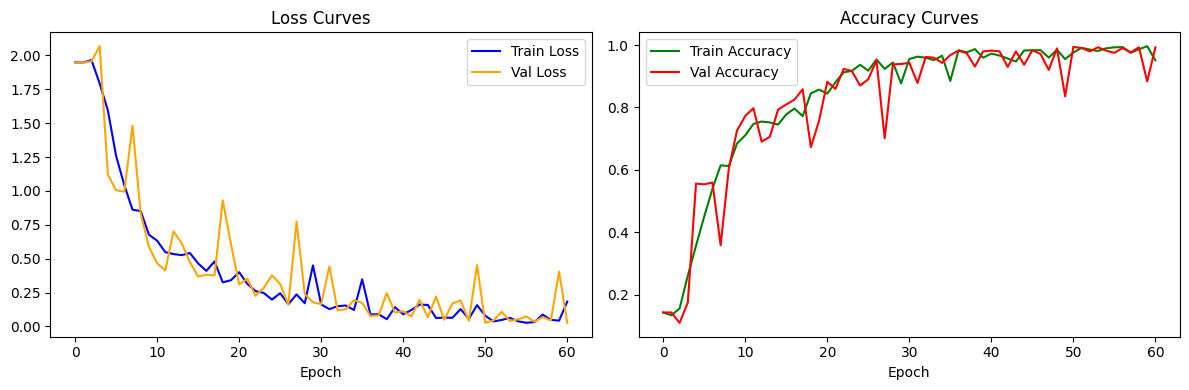

In [11]:
# Cell 12 — Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'], label='Train Loss', color='blue')
ax1.plot(history.history['val_loss'], label='Val Loss', color='orange')
ax1.set_title('Loss Curves'); ax1.legend(); ax1.set_xlabel('Epoch')
ax2.plot(history.history['accuracy'], label='Train Accuracy', color='green')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy', color='red')
ax2.set_title('Accuracy Curves'); ax2.legend(); ax2.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'training_curves.png'), dpi=150)
plt.show()

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step

=== TEST SET RESULTS ===
              precision    recall  f1-score   support

     neutral     0.9917    1.0000    0.9959       120
       happy     0.9600    1.0000    0.9796       120
         sad     0.9752    0.9833    0.9793       120
       angry     0.9915    0.9667    0.9789       120
        fear     0.9754    0.9917    0.9835       120
     disgust     0.9915    0.9667    0.9789       120
    surprise     1.0000    0.9750    0.9873       120

    accuracy                         0.9833       840
   macro avg     0.9836    0.9833    0.9833       840
weighted avg     0.9836    0.9833    0.9833       840



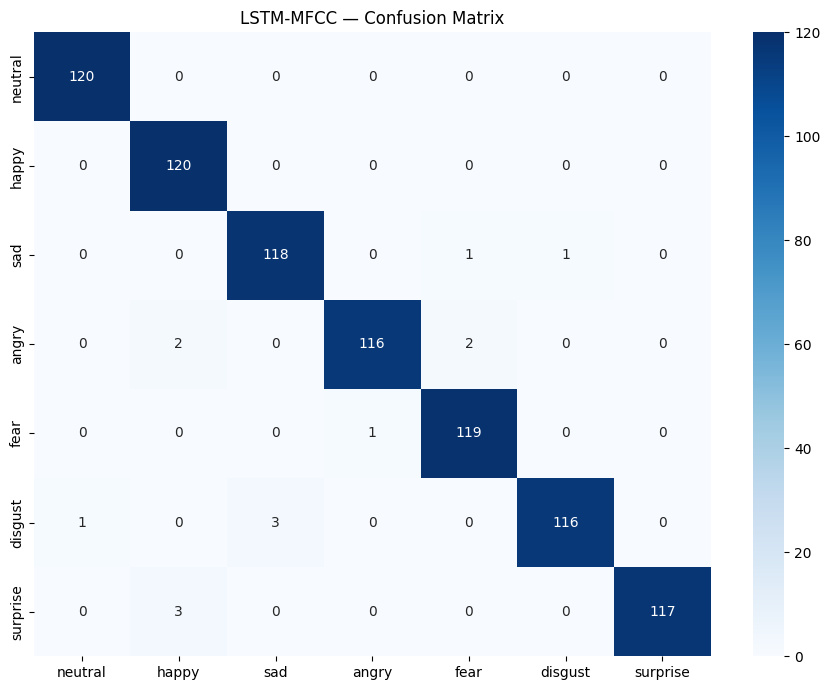

In [12]:
# Cell 13 — Test evaluation
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=-1)

test_accuracy  = accuracy_score(y_test, y_pred)
test_f1        = f1_score(y_test, y_pred, average='macro', zero_division=0)
test_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
test_recall    = recall_score(y_test, y_pred, average='macro', zero_division=0)

print('\n=== TEST SET RESULTS ===')
print(classification_report(y_test, y_pred, target_names=LABEL_NAMES, labels=range(len(LABEL_NAMES)), digits=4, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=range(len(LABEL_NAMES)))
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, cmap='Blues')
plt.title('LSTM-MFCC — Confusion Matrix'); plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'confusion_matrix.png'), dpi=150); plt.show()

In [13]:
results = {
    'model_id': CONFIG['model_id'], 'model_name': CONFIG['model_name'], 'track': CONFIG['track'],
    'accuracy': round(float(test_accuracy), 4), 'f1_macro': round(float(test_f1), 4),
    'precision_macro': round(float(test_precision), 4), 'recall_macro': round(float(test_recall), 4),
    'train_time_minutes': round(total_train_time / 60, 2),
    'peak_vram_gb': 0.0,  # Keras doesn't expose GPU mem easily
    'epochs_trained': best_epoch, 'dataset': CONFIG['dataset'],
    'saved_model_path': CONFIG['output_dir'], 'timestamp': time.strftime('%Y-%m-%d %H:%M:%S')
}
summary_path = os.path.join('..', '..', 'outputs', 'training_summary.json')
os.makedirs(os.path.join('..', '..', 'outputs'), exist_ok=True)
if os.path.exists(summary_path):
    with open(summary_path, 'r') as f: summary = json.load(f)
    summary = [r for r in summary if r['model_id'] != CONFIG['model_id']]
else: summary = []
summary.append(results)
with open(summary_path, 'w') as f: json.dump(summary, f, indent=2)
print(f'✓ Results saved'); print(json.dumps(results, indent=2))

✓ Results saved
{
  "model_id": "S1",
  "model_name": "LSTM-MFCC-Baseline (Keras)",
  "track": "SER",
  "accuracy": 0.9833,
  "f1_macro": 0.9833,
  "precision_macro": 0.9836,
  "recall_macro": 0.9833,
  "train_time_minutes": 26.64,
  "peak_vram_gb": 0.0,
  "epochs_trained": 51,
  "dataset": "TESS (2800 files, 7 emotions)",
  "saved_model_path": "..\\..\\outputs\\S1_lstm_mfcc_baseline",
  "timestamp": "2026-03-18 18:45:39"
}


## Training Complete ✓
**Next step**: Open **S2_whisper_large_ser.ipynb**